In [3]:
import pandas
from numpy import poly1d, polyfit
from src.energiapy.components.temporal_scale import Temporal_scale
from src.energiapy.components.resource import Resource
from src.energiapy.components.process import Process
from src.energiapy.components.material import Material
from src.energiapy.components.location import Location
from src.energiapy.components.network import Network
from src.energiapy.components.scenario import Scenario
from src.energiapy.components.transport import Transport
from src.energiapy.components.result import Result
from src.energiapy.model.formulate_milp import formulate_milp
from src.energiapy.utils.data_utils import get_data, make_henry_price_df
from src.energiapy.utils.nsrdb_utils import fetch_nsrdb_data
from src.energiapy.plot import plot
from src.energiapy.model.pyomo_solve import solve
from src.energiapy.utils.cluster_utils import reduce_scenario, agg_hierarchial_elbow, Clustermethod
from src.energiapy.utils.data_utils import load_results
from src.energiapy.model.pyomo_sets import generate_sets
from src.energiapy.model.pyomo_vars import *
from src.energiapy.model.pyomo_cons import *
from src.energiapy.model.pyomo_objs import cost_objective, uncertainty_cost_objective, demand_objective
import matplotlib.pyplot as plt
from pyomo.environ import ConcreteModel, Suffix
import random
from matplotlib import rc

In [4]:
weather20_df = pandas.read_csv('data/ho_solar20.csv', index_col=0)
weather20_df.index = [i.split('+')[0] for i in weather20_df.index]
weather = weather20_df[~weather20_df.index.str.contains('02-29')] #remove leap years
weather

,wind_speed,dni
2020-01-01 00:00:00,9.5,0.0
2020-01-01 01:00:00,7.5,0.0
2020-01-01 02:00:00,6.0,0.0
2020-01-01 03:00:00,6.0,0.0
2020-01-01 04:00:00,6.0,0.0
...,...,...
2020-12-31 19:00:00,54.5,0.5
2020-12-31 20:00:00,55.5,0.0
2020-12-31 21:00:00,50.0,0.0
2020-12-31 22:00:00,46.0,181.5


In [5]:
ercot20 = pandas.read_excel('data/Native_Load_2020.xlsx')
ercot = ercot20[['COAST']]
ercot['index'] = weather20_df.index
ercot = ercot.set_index('index')
ercot = ercot[~ercot.index.str.contains('02-29')]
ercot

C:\Users\cacodcar\AppData\Local\Temp\ipykernel_14776\4195252575.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ercot['index'] = weather20_df.index


,COAST
index,
2020-01-01 00:00:00,9890.091522
2020-01-01 01:00:00,9751.586415
2020-01-01 02:00:00,9603.421087
2020-01-01 03:00:00,9501.585599
2020-01-01 04:00:00,9499.426925
...,...
2020-12-31 19:00:00,12068.071946
2020-12-31 20:00:00,11818.903690
2020-12-31 21:00:00,11560.408167


In [6]:
ng_price20 = make_henry_price_df(
    file_name='data/Henry_Hub_Natural_Gas_Spot_Price_Daily.csv', year=2020, stretch=True)
ng_price_df = ng_price20
ng_price_df['index'] = weather.index
ng_price_df = ng_price_df.drop(columns= 'scales')
ng_price_stretch = ng_price_df.set_index('index')

In [7]:
cost_dict = get_data(file_name='data/cost_dict')
for i in cost_dict['HO']['moderate'].keys():
    print(i + ':', cost_dict['HO']['moderate'][i]['0'])

LiI_c: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
LiI_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
CAES_c: {'CAPEX': 1669000.0, 'Fixed O&M': 16700.0, 'Variable O&M': 0, 'units': '$/MW', 'source': 'https://www.pnm.com/documents/396023/1506047/2017+-+HDR+10-30-17+PNM+Energy+Storage+Report.pdf/a2b7ca65-e1ba-92c8-308a-9a8391a87331'}
CAES_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PSH_c: {'CAPEX': 0, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 4435.188, 'units': '$/MW', 'source': 'NREL Annual Technology Baseline 2021, https://atb.nrel.gov/'}
PSH_d: {'CAPEX': 0.001, 'Fixed O&M': 0.001, 'Variable O&M': 0, 'units': '$/MW', 'source': 'Dummy Process'}
PV: {'CAPEX': 1302181.81818181, 'Fixed O&M': 41432.7272727272, 'Variable O&M': 0, 'units': '$/MW', 'sour

In [8]:
bigM = 10**3  # very large number
smallM = 0.1
water_price = 31.70  # $/5000gallons
power_price = 8  # cents/kWh
ur_price = 42.70  # 250 Pfund U308 (Uranium)
A_f = 0.05  # annualization factor
# CO2_res = 0.2
pv_start = 0
ake_start = 0
smrh_start = 0
smr_start = 0
asmr_start = 0


In [9]:
Charge = Resource(name='Charge', sell=False,
                  store_max=bigM, basis='MW', label='Battery energy', block='energystorage')
Solar = Resource(
    name='Solar', cons_max=bigM, basis='MW', label='Solar Power', block='energyfeedstock')
Wind = Resource(name='Wind', cons_max= bigM, basis='MW', label='Wind Power', block='energyfeedstock')
H2_L = Resource(name='H2_L', store_max=10**4, revenue=2,
                mile=1/(0.1180535*1.60934), basis='kg', label='Hydrogen - Geological', block='resourcestorage')
H2 = Resource(name='H2', basis='kg', sell = True, demand = True, label='Hydrogen', block='Resource')
H2O = Resource(name='H2O', cons_max=10**6,
               price= 0.001, basis='kg', label='Water', block='Resource')
            #    price=water_price/(5000*3.7854), basis='kg', label='Water', block='Resource')
O2 = Resource(name='O2', sell=True, loss=0.07,
              basis='kg', label='Oxygen', block='Resource')
CH4 = Resource(name='CH4', cons_max=10 **
               6, price=1, basis='kg', label='Natural gas', block='materialfeedstock')
CO2 = Resource(name='CO2', basis='kg',
               label='Carbon dioxide', block='Resource')
CO2_Vent = Resource(
    name='CO2_Vent', sell=True, basis='kg', label='Carbon dioxide - Vented', block='resourcedischarge')
# Power= Resource(name= 'Power', sell= True, store_max=0,   \
#    mile= (10**3)/(0.2167432**1.60934), label= 'Renewable power generated')
Power = Resource(name='Power', basis='MW',
                 label='Renewable power generated', block='Resource')

Uranium = Resource(name='Uranium', cons_max=(1/4.17*10**(-5))*bigM,
                   price=ur_price/(250/2), basis='kg', label='Uranium', block='energyfeedstock')

Air_C = Resource(name='Air_C', store_max=bigM, basis='MW',
                 label='CAES energy', block='energystorage')

H2O_E = Resource(name='H2O_E', store_max=bigM, basis='MW',
                 label='PSH energy', block='energystorage')

In [10]:
def declare_processes(p_fail):
    LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
        prod_max=5, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015', p_fail = p_fail)
    LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
        'units': '$/kg','source': 'dummy'}, \
        prod_max=5, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015', p_fail = p_fail)
    WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
                prod_max=100, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
                label='Wind mill array', citation='Use windtoolkit conversion', p_fail= p_fail)
    PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
                prod_max=bigM, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                    label='Solar photovoltaics (PV) array', citation='Use pvlib conversion', p_fail = p_fail)
    AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
                cost=cost_dict['HO']['moderate']['AKE']['0'], prod_max=bigM, trl='utility', block='material_production',
                label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper', p_fail= p_fail)  # 20.833 MW required to produce 1000t/day.H2
    SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.05, 'units': '$/kg', 'source': 'dummy'}, \
        conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                        block='material_production', label='Steam methane reforming', citation='Mosca 2020', p_fail= p_fail)
    H2_L_c = Process(name='H2_L_c', conversion={Power: -4.17*10**(-4), H2_L: 1, H2: -1}, cost={'CAPEX': 1000, 'Fixed O&M': 600, 'Variable O&M': 0.05,
                                                                                            'units': '$/kg', 'source': 'dummy'},
                    prod_max=bigM, gwp=0, trl='repurposed', block='material_storage', label='Hydrogen geological storage',
                    citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= p_fail)
    H2_L_d = Process(name='H2_L_d', conversion={H2_L: -1, H2: 1}, prod_max=bigM, gwp=0, trl='nocost', cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1,                                                                                                        'units': '$/kg', 'source': 'dummy'},
                    block='material_storage', label='Hydrogen geological storage discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= p_fail)
    ASMR = Process(name='ASMR', conversion={Uranium: -4.17*10**(-5), H2O: -3364.1, Power: 1}, cost=cost_dict['HO']['moderate']['ASMR']['0'],
                intro_scale=asmr_start, gwp=9100, prod_max=bigM, land=1100/1800, trl='pilot', block='power_generation', label='Small modular reactors (SMRs)', p_fail = p_fail)

    CAES_c = Process(name='CAES_c', conversion={Air_C: 1, Power: -1}, cost = cost_dict['HO']['moderate']['CAES_c']['0'], \
        intro_scale=0, prod_max=bigM, trl='pilot', block='power_storage', label='Compressed air energy storage (CAES)', citation='Zakeri 2015', p_fail= p_fail)

    CAES_d = Process(name='CAES_d', conversion={Air_C: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
        'units': '$/kg','source': 'dummy'},\
        intro_scale=0, prod_max=bigM, trl='discharge', block='power_storage', label='Compressed air energy storage (CAES) discharge', citation='Zakeri 2015', p_fail= p_fail)

    PSH_c = Process(name='PSH_c', conversion={H2O_E: 1, Power: -1}, cost = cost_dict['HO']['moderate']['PSH_c']['0'], \
        intro_scale=0, prod_max=bigM, trl='nrel', block='power_storage', label='Pumped storage hydropower (PSH)', citation='Zakeri 2015', p_fail= p_fail)

    PSH_d = Process(name='PSH_d', conversion={H2O_E: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
        'units': '$/kg','source': 'dummy'}, \
        prod_max=bigM, trl='discharge', block='power_storage', label='Pumped storage hydropower (PSH) discharge', citation='Zakeri 2015', p_fail= p_fail)
    
    return {LiI_c, LiI_d,  ASMR, AKE, SMR, H2_L_c, H2_L_d, CAES_c, CAES_d, PSH_c, PSH_d, PV, WF}, [PV, WF]
    

In [11]:
declare_processes(p_fail= 0.05)

({AKE,
  ASMR,
  CAES_c,
  CAES_d,
  H2_L_c,
  H2_L_d,
  LiI_c,
  LiI_d,
  PSH_c,
  PSH_d,
  PV,
  SMR,
  WF},
 [PV, WF])

In [12]:
scales = Temporal_scale(discretization_list=[1, 365, 24])

In [71]:
LiI_c = Process(name='LiI_c', conversion={Charge: 1, Power: -1}, cost = cost_dict['HO']['moderate']['LiI_c']['0'],\
    prod_max=5, trl='nrel', block='power_storage', label='Lithium-ion battery', citation='Zakeri 2015', p_fail = 0.05)
LiI_d = Process(name='LiI_d', conversion={Charge: -1.1765, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
    prod_max=5, trl='discharge', block='power_storage', label='Lithium-ion battery discharge', citation='Zakeri 2015', p_fail = 0.05)
WF = Process(name='WF', conversion={Wind: -1, Power: 1, H2O: -1}, cost=cost_dict['HO']['moderate']['WF']['0'],
            prod_max=100, gwp=52700, land=10800/1800, trl='nrel', block='power_generation',
            label='Wind mill array', citation='Use windtoolkit conversion', p_fail= 0.05)
PV = Process(name='PV', intro_scale=pv_start, conversion={Solar: -1, Power: 1, H2O: -20}, cost=cost_dict['HO']['moderate']['PV']['0'],
            prod_max=bigM, gwp=53000, land=13320/1800, trl='nrel', block='power_generation', \
                label='Solar photovoltaics (PV) array', citation='Use pvlib conversion', p_fail = 0.05)
AKE = Process(name='AKE', intro_scale=ake_start, conversion={Power: -1, H2: 19.474, O2: 763.2, H2O: -175.266},
            cost=cost_dict['HO']['moderate']['AKE']['0'], prod_max=bigM, trl='utility', block='material_production',
            label='Alkaline water electrolysis (AWE)', citation='Demirhan et al. 2018 AIChE paper', p_fail= 0.05)  # 20.833 MW required to produce 1000t/day.H2
SMR = Process(name='SMR', intro_scale=smr_start, cost= {'CAPEX': 2400, 'Fixed O&M': 800, 'Variable O&M': 0.05, 'units': '$/kg', 'source': 'dummy'}, \
    conversion={Power: -1.11*10**(-3), CH4: -3.76, H2O: -23.7, H2: 1, CO2_Vent: 9.4979}, prod_max=bigM, gwp=0, trl='enterprise',
                    block='material_production', label='Steam methane reforming', citation='Mosca 2020', p_fail= 0.05)
H2_L_c = Process(name='H2_L_c', conversion={Power: -4.17*10**(-4), H2_L: 1, H2: -1}, cost={'CAPEX': 1000, 'Fixed O&M': 600, 'Variable O&M': 0.05,
                                                                                        'units': '$/kg', 'source': 'dummy'},
                prod_max=bigM, gwp=0, trl='repurposed', block='material_storage', label='Hydrogen geological storage',
                citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= 0.05)
H2_L_d = Process(name='H2_L_d', conversion={H2_L: -1, H2: 1}, prod_max=bigM, gwp=0, trl='nocost', cost={'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': 1,                                                                                                        'units': '$/kg', 'source': 'dummy'},
                block='material_storage', label='Hydrogen geological storage discharge', citation='Bossel and Eliasson - Energy and the Hydrogen Economy', p_fail= 0.05)
ASMR = Process(name='ASMR', conversion={Uranium: -4.17*10**(-5), H2O: -3364.1, Power: 1}, cost=cost_dict['HO']['moderate']['ASMR']['0'],
            intro_scale=asmr_start, gwp=9100, prod_max=bigM, land=1100/1800, trl='pilot', block='power_generation', label='Small modular reactors (SMRs)', p_fail = 0.05)

CAES_c = Process(name='CAES_c', conversion={Air_C: 1, Power: -1}, cost = cost_dict['HO']['moderate']['CAES_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='pilot', block='power_storage', label='Compressed air energy storage (CAES)', citation='Zakeri 2015', p_fail= 0.05)

CAES_d = Process(name='CAES_d', conversion={Air_C: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'},\
    intro_scale=0, prod_max=bigM, trl='discharge', block='power_storage', label='Compressed air energy storage (CAES) discharge', citation='Zakeri 2015', p_fail= 0.05)

PSH_c = Process(name='PSH_c', conversion={H2O_E: 1, Power: -1}, cost = cost_dict['HO']['moderate']['PSH_c']['0'], \
    intro_scale=0, prod_max=bigM, trl='nrel', block='power_storage', label='Pumped storage hydropower (PSH)', citation='Zakeri 2015', p_fail= 0.05)

PSH_d = Process(name='PSH_d', conversion={H2O_E: -1.4286, Power: 1}, cost =  {'CAPEX': smallM, 'Fixed O&M': 0, 'Variable O&M': smallM, \
    'units': '$/kg','source': 'dummy'}, \
        prod_max=bigM, trl='discharge', block='power_storage', label='Pumped storage hydropower (PSH) discharge', citation='Zakeri 2015', p_fail= 0.05)

In [72]:
def MIP_formulation(scenario: Scenario,carbon_bound:float= None, \
    carbon_reduction_percentage:float= 0.0, demand:float= 0.0):
    instance = ConcreteModel()

    generate_sets(instance=instance, location_set=scenario.location_set, transport_set=scenario.transport_set, scales=scenario.scales,
                  process_set=scenario.process_set, resource_set=scenario.resource_set, material_set=scenario.material_set,
                  source_set=scenario.source_locations, sink_set=scenario.sink_locations)

    generate_scheduling_vars(
        instance=instance, scale_level=scenario.scheduling_scale_level)
    generate_network_vars(
        instance=instance, scale_level=scenario.network_scale_level)
    
    generate_network_binary_vars(
        instance=instance, scale_level=scenario.network_scale_level)

    generate_uncertainty_vars(
        instance=instance, scale_level=scenario.demand_scale_level)

    if len(instance.locations) > 1:
        generate_transport_vars(
            instance=instance, scale_level=scenario.scheduling_scale_level)

    inventory_balance_constraint(instance=instance, scheduling_scale_level=scenario.scheduling_scale_level,
                                 conversion=scenario.conversion)
    nameplate_production_constraint(instance=instance, capacity_factor=scenario.capacity_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)
    
    nameplate_inventory_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level,
                                   scheduling_scale_level=scenario.scheduling_scale_level)
    resource_consumption_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict,
                                    cons_max=scenario.cons_max, scheduling_scale_level=scenario.scheduling_scale_level)
    resource_purchase_constraint(instance=instance, cost_factor=scenario.cost_factor, price=scenario.price,
                                 loc_res_dict=scenario.loc_res_dict, scheduling_scale_level=scenario.scheduling_scale_level,
                                 expenditure_scale_level=scenario.expenditure_scale_level)
    
    nameplate_production_failure_constraint(instance=instance, fail_factor=scenario.fail_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)

    production_facility_constraint(instance=instance, prod_max=scenario.prod_max,
                                   loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    storage_facility_constraint(instance=instance, store_max=scenario.store_max,
                                loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)
    
    location_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)

    network_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    process_capex_constraint(instance=instance, capex_dict=scenario.capex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_fopex_constraint(instance=instance, fopex_dict=scenario.fopex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_vopex_constraint(instance=instance, vopex_dict=scenario.vopex_dict,
                             network_scale_level=scenario.network_scale_level)

    process_land_constraint(instance=instance, land_dict=scenario.land_dict,
                            network_scale_level=scenario.network_scale_level)
    location_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    location_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    network_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)


    demand_constraint(instance=instance, demand_scale_level=scenario.demand_scale_level,
                      scheduling_scale_level=scenario.scheduling_scale_level, demand = demand, \
                          demand_factor=scenario.demand_factor)
    
    if carbon_bound is not None:
        carbon_emission_constraint(instance= instance, network_scale_level= scenario.network_scale_level, \
            carbon_reduction_percentage = carbon_reduction_percentage, carbon_bound = carbon_bound)
    
    instance.dual = Suffix(direction=Suffix.IMPORT)


    cost_objective(instance=instance, network_scale_level=scenario.network_scale_level)
    
    
    # demand_objective(instance=instance, network_scale_level =scenario.network_scale_level)
    
    

    return instance

In [75]:
process_set = [LiI_c, LiI_d,  ASMR, AKE, SMR, H2_L_c, H2_L_d, CAES_c, CAES_d, PSH_c, PSH_d, PV, WF]
HO = Location(name='HO', processes= process_set, scales=scales, label='Houston', \
        demand_factor= {H2: ercot}, cost_factor = {CH4: ng_price_stretch}, \
            capacity_factor = {PV: pandas.DataFrame(weather['dni']), WF: pandas.DataFrame(weather['wind_speed'])}\
                , demand_level=2, capacity_level= 2, cost_level= 2)
scenario = Scenario(name= 'shell', network= HO, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
        network_scale_level= 0, demand_scale_level= 2, label= 'shell milp case study (HO)', )
reduced_scenario, rep_days_stretch,  info =  reduce_scenario(
        scenario=scenario, location= HO, periods=40, scale_level=1, method=Clustermethod.agg_hierarchial,\
            include = ['demand', 'capacity', 'cost'])


In [81]:
MILP = MIP_formulation(scenario= reduced_scenario, demand = 1000)
results_reduced = solve(scenario = reduced_scenario, instance= MILP, solver= 'gurobi', \
                name=f"mickey_mouse (reduced)", print_solversteps = True)

Set parameter QCPDual to value 1
Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 51969 rows, 29908 columns and 144563 nonzeros
Model fingerprint: 0x99c72f0b
Variable types: 29891 continuous, 17 integer (17 binary)
Coefficient statistics:
  Matrix range     [4e-05, 3e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-03, 1e+06]
Presolve removed 34572 rows and 14276 columns
Presolve time: 0.11s
Presolved: 17397 rows, 15632 columns, 52763 nonzeros
Variable types: 15632 continuous, 0 integer (0 binary)

Root relaxation: objective 4.856066e+07, 17919 iterations, 2.60 seconds (3.64 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    4.856066e+07 4.8561e+07  0.00%     -    2s

Explored 1 nodes (17919 sim

In [32]:
list_ = [0.05, 0.01, 0.02, 0.04, 0.08, 0.16]

results_fail = {i:0 for i in list_}
for p_fail in list_:
    process_set = declare_processes(p_fail= p_fail)
    HO = Location(name='HO', processes= process_set[0], scales=scales, label='Houston', \
        demand_factor= {H2: ercot}, cost_factor = {CH4: ng_price_stretch}, \
            capacity_factor = {process_set[1][0]: pandas.DataFrame(weather['dni']), process_set[1][0]: pandas.DataFrame(weather['wind_speed'])}\
                , demand_level=2, capacity_level= 2, cost_level= 2)
    scenario = Scenario(name= 'shell', network= HO, scales= scales,  expenditure_scale_level= 2, scheduling_scale_level= 2, \
        network_scale_level= 0, demand_scale_level= 2, label= 'shell milp case study (HO)', )
    reduced_scenario, rep_days_stretch,  info =  reduce_scenario(
        scenario=scenario, location= HO, periods=40, scale_level=1, method=Clustermethod.agg_hierarchial,\
            include = ['demand', 'capacity', 'cost'])

    MILP = MIP_formulation(scenario= reduced_scenario, demand = 1000)
    result = solve(scenario = reduced_scenario, instance= MILP, solver= 'gurobi', \
                    name=f"mickey_mouse (reduced)", print_solversteps = True)
    results_fail[p_fail] = result

Set parameter QCPDual to value 1
Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 51969 rows, 29908 columns and 144602 nonzeros
Model fingerprint: 0xbd2e5ea1
Variable types: 29891 continuous, 17 integer (17 binary)
Coefficient statistics:
  Matrix range     [4e-05, 3e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-03, 1e+06]
Presolve removed 34501 rows and 14253 columns
Presolve time: 0.12s
Presolved: 17468 rows, 15655 columns, 52987 nonzeros
Variable types: 15655 continuous, 0 integer (0 binary)

Root relaxation: objective 4.650221e+07, 18611 iterations, 2.70 seconds (3.20 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    4.650221e+07 4.6502e+07  0.00%     -    2s

Explored 1 nodes (18611 sim

In [33]:
# results_fail
obj = [i.output['objective']  if i.output['termination'] == 'optimal' else 0 for i in results_fail.values()]

In [20]:
for i in list(results_fail.keys()):
    print(results_fail[i].output['Cap_P'][('HO', 'WF', 0)])

1.2376352680484168
0.36084133838951954


KeyError: 'Cap_P'

In [68]:
print('SMR', 'AKE', 'ASMR', 'WF', 'PV', 'H2_L_c', 'CAES_c', 'PSH_c')
for i in [0.01, 0.02, 0.04, 0.08]:
    print(results_fail[i].output['Cap_P'][('HO', 'SMR', 0)], results_fail[i].output['Cap_P'][('HO', 'AKE', 0)], \
        results_fail[i].output['Cap_P'][('HO', 'ASMR', 0)], results_fail[i].output['Cap_P'][('HO', 'WF', 0)], \
            results_fail[i].output['Cap_P'][('HO', 'PV', 0)], results_fail[i].output['Cap_P'][('HO', 'H2_L_c', 0)], \
                results_fail[i].output['Cap_P'][('HO', 'CAES_c', 0)], results_fail[i].output['Cap_P'][('HO', 'PSH_c', 0)],\
                    results_fail[i].output['Cap_P'][('HO', 'LiI_c', 0)]) 

    

SMR AKE ASMR WF PV H2_L_c CAES_c PSH_c
1000.0 0.0 0.0 1.1422761432949413 0.0 441.19044878086555 0.003270111364675968 0.0 0.08623926469345015
1000.0 29.768384559266565 0.0 0.490451547514285 1.2564583073794258 442.2194602585988 0.39240988084761796 0.4156210781774018 0.09804166666666667
1000.0 38.01886156982016 0.0 0.8714192315916973 0.5603311664586766 458.05361045707025 0.14681327098281097 0.0 0.04875785528268481
668.91747267131 38.44561554908569 0.0 4.559813705325482 20.013800833590857 289.0534216714625 0.059568542687653665 0.26599447920463776 0.09527156594190143


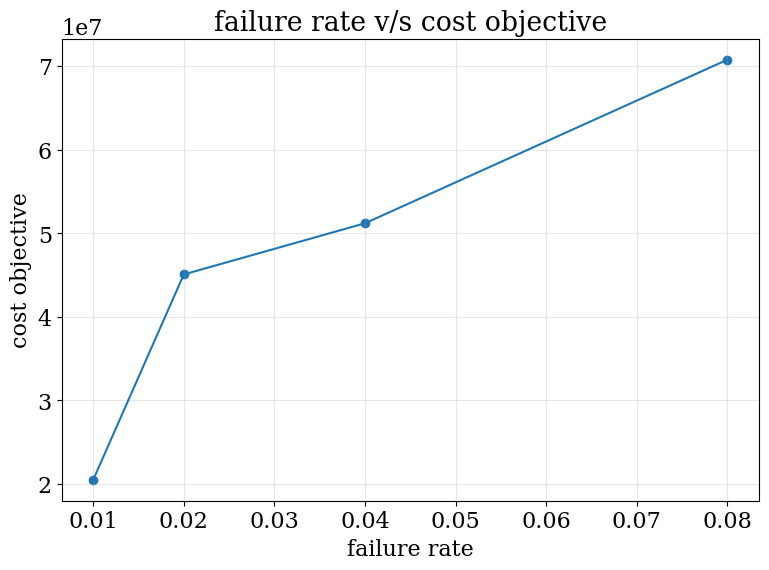

In [66]:
x_ = [0.01, 0.02, 0.04, 0.08]
y_ = obj[1:-1]

# theta  = polyfit(x= x,  y= y, deg=2)
    # theta  = np.polyfit(x=[i+10 for i in range(70)],  y= wcss1, deg=3)

# y_line = [theta[2] + theta[1] * pow(i, 1) + theta[0] * pow(i, 2) for i in x]
# y_line = [theta[3] + theta[2] * pow(i, 1) + theta[1] * pow(i, 2) + theta[0] * pow(i, 3) for i in x]
# y_line = [theta[4] + theta[3] * pow(i, 1) + theta[2] * pow(i, 2) + theta[1] * pow(i, 3) + theta[0]*pow(i,4) for i in x]

rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize = (9,6))
ax.scatter(x_, y_)
ax.plot(x_, y_)
plt.title(f'failure rate v/s cost objective')
plt.ylabel(f'cost objective')
plt.xlabel(f'failure rate')
plt.grid(alpha = 0.3)
plt.rcdefaults()

In [ ]:
results_reduced.output['Cap_P']

In [ ]:
demand_list = [100*i for i in range(13)]
objectives_d = {i: 0 for i in demand_list}
def solve_diff_demand(demand_list: list):
    for demand in demand_list:
        MILP = MIP_formulation(scenario= reduced_scenario, demand = demand)
        results_reduced = solve(scenario = reduced_scenario, instance= MILP, solver= 'gurobi', \
            name=f"mickey_mouse (reduced)", print_solversteps = True)
        objectives_d[demand] = results_reduced
        
    return objectives_d
objectives_d = solve_diff_demand(demand_list= demand_list)    

In [ ]:
y = [objectives_d[j].output['objective'] for j in [100*i for i in range(12)]]
x = [100*i for i in range(12)]

rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize = (9,6))
ax.plot(x, y)
plt.title(f'demand v/s cost objective')
plt.ylabel(f'cost objective')
plt.xlabel(f'demand')
plt.rcdefaults()

In [ ]:
plt.plot(reduced_scenario.fail_factor['HO']['AKE'].values())
plt.show()
plt.plot(reduced_scenario.fail_factor['HO']['SMR'].values())
plt.show()

In [77]:

def flexibility_MIP_reformulation(scenario: Scenario, affix_results: Result = None, carbon_bound:float= None, \
    carbon_reduction_percentage:float= 0.0, penalty:float = 0.0, demand:float= 0.0):
    instance = ConcreteModel()

    generate_sets(instance=instance, location_set=scenario.location_set, transport_set=scenario.transport_set, scales=scenario.scales,
                  process_set=scenario.process_set, resource_set=scenario.resource_set, material_set=scenario.material_set,
                  source_set=scenario.source_locations, sink_set=scenario.sink_locations)

    generate_scheduling_vars(
        instance=instance, scale_level=scenario.scheduling_scale_level)
    generate_network_vars(
        instance=instance, scale_level=scenario.network_scale_level)
    
    generate_network_binary_vars(
        instance=instance, scale_level=scenario.network_scale_level)

    generate_uncertainty_vars(
        instance=instance, scale_level=scenario.demand_scale_level)

    if len(instance.locations) > 1:
        generate_transport_vars(
            instance=instance, scale_level=scenario.scheduling_scale_level)

    inventory_balance_constraint(instance=instance, scheduling_scale_level=scenario.scheduling_scale_level,
                                 conversion=scenario.conversion)
    nameplate_production_constraint(instance=instance, capacity_factor=scenario.capacity_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)
    
    nameplate_inventory_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level,
                                   scheduling_scale_level=scenario.scheduling_scale_level)
    resource_consumption_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict,
                                    cons_max=scenario.cons_max, scheduling_scale_level=scenario.scheduling_scale_level)
    resource_purchase_constraint(instance=instance, cost_factor=scenario.cost_factor, price=scenario.price,
                                 loc_res_dict=scenario.loc_res_dict, scheduling_scale_level=scenario.scheduling_scale_level,
                                 expenditure_scale_level=scenario.expenditure_scale_level)
    
    nameplate_production_failure_constraint(instance=instance, fail_factor=scenario.fail_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)
    
    production_facility_affix_constraint(instance=instance, affix_production_cap = affix_results.output['Cap_P'],
                                   loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    
    storage_facility_affix_constraint(instance=instance, affix_storage_cap = affix_results.output['Cap_S'],
                                loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)

    location_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)

    network_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    process_capex_constraint(instance=instance, capex_dict=scenario.capex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_fopex_constraint(instance=instance, fopex_dict=scenario.fopex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_vopex_constraint(instance=instance, vopex_dict=scenario.vopex_dict,
                             network_scale_level=scenario.network_scale_level)

    process_land_constraint(instance=instance, land_dict=scenario.land_dict,
                            network_scale_level=scenario.network_scale_level)
    location_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    location_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    network_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)


    demand_constraint_flex(instance=instance, demand_scale_level=scenario.demand_scale_level,
                      scheduling_scale_level=scenario.scheduling_scale_level, demand = demand, \
                          demand_factor=scenario.demand_factor)
    
    if carbon_bound is not None:
        carbon_emission_constraint(instance= instance, network_scale_level= scenario.network_scale_level, \
            carbon_reduction_percentage = carbon_reduction_percentage, carbon_bound = carbon_bound)
    
    instance.dual = Suffix(direction=Suffix.IMPORT)


    uncertainty_cost_objective(instance=instance,
                   network_scale_level=scenario.network_scale_level, uncertainty_scale_level =\
                       scenario.demand_scale_level, penalty = penalty)
    
    
    # demand_objective(instance=instance, network_scale_level =scenario.network_scale_level)
    
    

    return instance

In [82]:
objectives_p = {i*15:0 for i in range(10)}
def solve_many(penalty_list: list):    
    for penalty in penalty_list:
        flex_MILP = flexibility_MIP_reformulation(scenario= reduced_scenario, penalty =  penalty, demand = 1000,\
            affix_results=  results_reduced)

        results_reduced_affix = solve(scenario = reduced_scenario, instance= flex_MILP, solver= 'gurobi', \
            name=f"mickey_mouse (reduced)")
        
        objectives_p[penalty] = results_reduced_affix
        
    return objectives_p


In [83]:
objectives_p = solve_many([15*i for i in range(15)])

Set parameter QCPDual to value 1
Gurobi Optimizer version 9.5.2 build v9.5.2rc0 (win64)
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads
Optimize a model with 51969 rows, 29908 columns and 145506 nonzeros
Model fingerprint: 0x2f0d19a4
Variable types: 29891 continuous, 17 integer (17 binary)
Coefficient statistics:
  Matrix range     [4e-05, 3e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-03, 1e+06]
Presolve removed 45585 rows and 13625 columns
Presolve time: 0.08s
Presolved: 6384 rows, 16283 columns, 31639 nonzeros
Variable types: 16283 continuous, 0 integer (0 binary)

Root relaxation: objective 3.172801e+07, 0 iterations, 0.01 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0    3.172801e+07 3.1728e+07  0.00%     -    0s

Explored 1 nodes (0 simplex iter

In [ ]:
objectives_p[15].output['Cap_S']

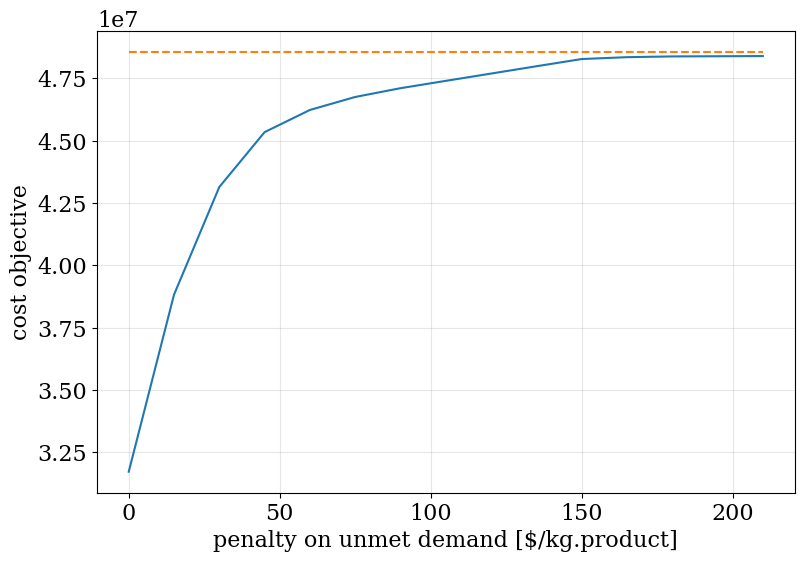

In [94]:
y = [objectives_p[j].output['objective'] for j in [15*i for i in range(15)]]
x = [15*i for i in range(15)]
y_ = [4.856065820633e+07 for _ in range(15)]
# y = [objectives_p[j].output['Cap_P'][('HO', 'SMR', 0)] for j in x]


# y = [list(objectives_p[j].output['Demand_slack'].values()) for j in [15*i for i in range(11)]]
# x = [15*i for i in range(11)]

rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], 'size': 16})
fig, ax = plt.subplots(figsize = (9,6))
ax.plot(x, y)
ax.plot(x,y_, '--')
# plt.title(f'Capacity ')
plt.ylabel(f'cost objective')
plt.xlabel(f'penalty on unmet demand [$/kg.product]')
plt.grid(alpha = 0.3)
plt.rcdefaults()

In [80]:
for i, j in product([1, 4, 5, 6, 8], [100000, 200000, 300000, 400000 ]):

    flex_MILP = flexibility_MIP_reformulation(scenario= reduced_scenario, penalty =  i, demand = j)
    results_reduced = solve(scenario = reduced_scenario, instance= flex_MILP, solver= 'gurobi', \
        name=f"mickey_mouse (reduced)", print_solversteps = False)
    
    print(i, j, results_reduced.output['objective'])


AttributeError: 'NoneType' object has no attribute 'output'

In [ ]:

def MILP_demand(scenario: Scenario, affix_results: Result = None, carbon_bound:float= None, \
    carbon_reduction_percentage:float= 0.0, penalty:float = 0.0, demand:float= 0.0):
    instance = ConcreteModel()

    generate_sets(instance=instance, location_set=scenario.location_set, transport_set=scenario.transport_set, scales=scenario.scales,
                  process_set=scenario.process_set, resource_set=scenario.resource_set, material_set=scenario.material_set,
                  source_set=scenario.source_locations, sink_set=scenario.sink_locations)

    generate_scheduling_vars(
        instance=instance, scale_level=scenario.scheduling_scale_level)
    generate_network_vars(
        instance=instance, scale_level=scenario.network_scale_level)
    
    generate_network_binary_vars(
        instance=instance, scale_level=scenario.network_scale_level)

    generate_uncertainty_vars(
        instance=instance, scale_level=scenario.demand_scale_level)

    if len(instance.locations) > 1:
        generate_transport_vars(
            instance=instance, scale_level=scenario.scheduling_scale_level)

    inventory_balance_constraint(instance=instance, scheduling_scale_level=scenario.scheduling_scale_level,
                                 conversion=scenario.conversion)
    nameplate_production_constraint(instance=instance, capacity_factor=scenario.capacity_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)
    
    nameplate_inventory_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level,
                                   scheduling_scale_level=scenario.scheduling_scale_level)
    resource_consumption_constraint(instance=instance, loc_res_dict=scenario.loc_res_dict,
                                    cons_max=scenario.cons_max, scheduling_scale_level=scenario.scheduling_scale_level)
    resource_purchase_constraint(instance=instance, cost_factor=scenario.cost_factor, price=scenario.price,
                                 loc_res_dict=scenario.loc_res_dict, scheduling_scale_level=scenario.scheduling_scale_level,
                                 expenditure_scale_level=scenario.expenditure_scale_level)
    
    nameplate_production_failure_constraint(instance=instance, fail_factor=scenario.fail_factor,
                                    network_scale_level=scenario.network_scale_level, scheduling_scale_level=scenario.scheduling_scale_level)
    
    # production_facility_affix_constraint(instance=instance, affix_production_cap = affix_results.output['Cap_P'],
    #                                loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    
    # storage_facility_affix_constraint(instance=instance, affix_storage_cap = affix_results.output['Cap_S'],
    #                             loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)

    production_facility_constraint(instance=instance, prod_max=scenario.prod_max,
                                   loc_pro_dict=scenario.loc_pro_dict, network_scale_level=scenario.network_scale_level)
    storage_facility_constraint(instance=instance, store_max=scenario.store_max,
                                loc_res_dict=scenario.loc_res_dict, network_scale_level=scenario.network_scale_level)
    
    location_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)
    location_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level, cluster_wt=scenario.cluster_wt)

    network_production_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_discharge_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_consumption_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_purchase_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    process_capex_constraint(instance=instance, capex_dict=scenario.capex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_fopex_constraint(instance=instance, fopex_dict=scenario.fopex_dict,
                             network_scale_level=scenario.network_scale_level)
    process_vopex_constraint(instance=instance, vopex_dict=scenario.vopex_dict,
                             network_scale_level=scenario.network_scale_level)

    process_land_constraint(instance=instance, land_dict=scenario.land_dict,
                            network_scale_level=scenario.network_scale_level)
    location_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_land_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    location_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    location_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)

    network_capex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_fopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)
    network_vopex_constraint(
        instance=instance, network_scale_level=scenario.network_scale_level)


    demand_constraint_flex(instance=instance, demand_scale_level=scenario.demand_scale_level,
                      scheduling_scale_level=scenario.scheduling_scale_level, demand = 4.87398e+08/40, \
                          demand_factor=scenario.demand_factor)
    
    if carbon_bound is not None:
        carbon_emission_constraint(instance= instance, network_scale_level= scenario.network_scale_level, \
            carbon_reduction_percentage = carbon_reduction_percentage, carbon_bound = carbon_bound)
    
    instance.dual = Suffix(direction=Suffix.IMPORT)

    
    demand_objective(instance=instance, network_scale_level =scenario.network_scale_level)
    
    

    return instance

In [ ]:
flex_MILP = MILP_demand(scenario= reduced_scenario)
results_reduced = solve(scenario = reduced_scenario, instance= flex_MILP, solver= 'gurobi', \
    name=f"mickey_mouse (reduced)", print_solversteps = True)
